Dataset Shape: (569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_wors

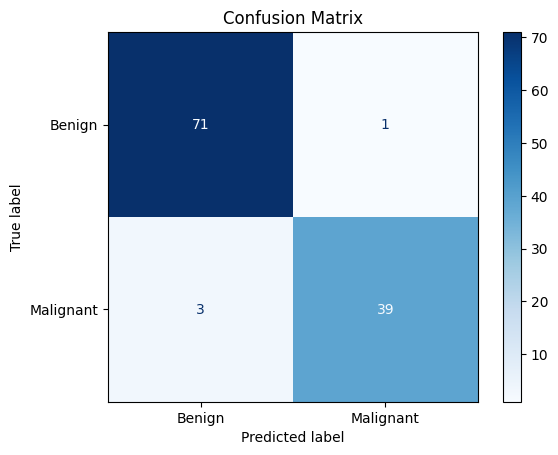

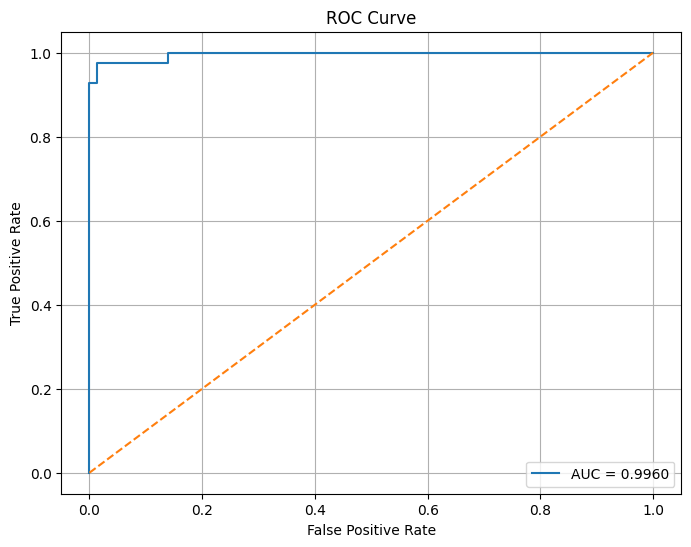


Results with Threshold = 0.3
Precision: 0.9761904761904762
Recall: 0.9761904761904762

Top Influential Features:
                Feature  Coefficient
21        texture_worst     1.429023
10            radius_se     1.237079
28       symmetry_worst     1.062661
7   concave points_mean     0.948610
13              area_se     0.913437
26      concavity_worst     0.911943
23           area_worst     0.904637
20         radius_worst     0.895402
6        concavity_mean     0.779010
12         perimeter_se     0.750503


In [1]:
# ==========================================
# Task 4: Classification with Logistic Regression
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
df = pd.read_csv(r"C:\Users\Bhargavi sai\Downloads\data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ------------------------------------------
# 2. Data Cleaning
# ------------------------------------------

# Remove unnecessary columns
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

# Convert target variable
# M = 1 (Malignant)
# B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Features and Target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# ------------------------------------------
# 3. Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# 4. Standardize Features
# ------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------
# 5. Train Logistic Regression Model
# ------------------------------------------
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

# ------------------------------------------
# 6. Predictions
# ------------------------------------------
y_pred = model.predict(X_test_scaled)

# Probability predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------
# 7. Evaluation Metrics
# ------------------------------------------
print("\nClassification Report")
print(classification_report(y_test, y_pred))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Precision :", precision)
print("Recall    :", recall)
print("ROC-AUC   :", roc_auc)

# ------------------------------------------
# 8. Confusion Matrix
# ------------------------------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ------------------------------------------
# 9. ROC Curve
# ------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------
# 10. Threshold Tuning
# ------------------------------------------
custom_threshold = 0.30

y_pred_custom = (y_prob >= custom_threshold).astype(int)

print("\nResults with Threshold =", custom_threshold)

print("Precision:",
      precision_score(y_test, y_pred_custom))

print("Recall:",
      recall_score(y_test, y_pred_custom))

# ------------------------------------------
# 11. Logistic Regression Coefficients
# ------------------------------------------
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nTop Influential Features:")
print(coef_df.head(10))